## Exploratory Data Analysis: Reading CSV Files

## Loading CSV Files from Google Drive

First, we need to mount Google Drive to access its contents.

#Got dataframe from 01_data_prep.ipynb/workbooks/Ramnik_Preprocessing.ipynb through cloning that notebook, and building on top of it for EDA and visualizations

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Now that Google Drive is mounted, let's define the path to your 'Exploratory Data Analysis' folder and list all `.csv` files within it.

In [2]:
import os
import pandas as pd

# Define the correct path to the user's Google Drive folder
drive_data_path = '/content/drive/MyDrive/207 Final Project/Exploratory Data Analysis/'

# Check if the directory exists
if not os.path.exists(drive_data_path):
    print(f"Error: The directory '{drive_data_path}' does not exist or is not accessible.")
    print("Please ensure the folder name is correct and Google Drive is mounted successfully.")
else:
    print(f"Files in '{drive_data_path}':")
    csv_files = [f for f in os.listdir(drive_data_path) if f.endswith('.csv')]
    if csv_files:
        for file_name in csv_files:
            print(file_name)
    else:
        print("No CSV files found in this directory.")

Files in '/content/drive/MyDrive/207 Final Project/Exploratory Data Analysis/':
yelp_academic_dataset_business.csv
yelp_academic_dataset_checkin.csv
yelp_academic_dataset_tip.csv
yelp_academic_dataset_user.csv
yelp_academic_dataset_review.csv


Next, I will load each identified CSV file into a pandas DataFrame and display its first 5 rows.

In [3]:
import pandas as pd
import os

drive_data_path = '/content/drive/MyDrive/207 Final Project/Exploratory Data Analysis/'

# Filter for only the requested CSV files
requested_files = ['yelp_academic_dataset_business.csv', 'yelp_academic_dataset_review.csv']
csv_files = [f for f in os.listdir(drive_data_path) if f.endswith('.csv') and f in requested_files]

if csv_files:
    for file_name in csv_files:
        file_path = os.path.join(drive_data_path, file_name)
        print(f"\n--- Loading '{file_name}' ---")
        try:
            # Create a clean variable name for the DataFrame
            df_var_name = file_name.replace('.csv', '').replace(' ', '_').replace('-', '_').lower()
            globals()[f'{df_var_name}_df'] = pd.read_csv(file_path)
            print(f"DataFrame '{df_var_name}_df' loaded successfully. First 5 rows:")
            display(globals()[f'{df_var_name}_df'].head())
        except Exception as e:
            print(f"Error loading '{file_name}': {e}")
else:
    print("No requested CSV files found to load from this directory.")


--- Loading 'yelp_academic_dataset_business.csv' ---


/tmp/ipykernel_36114/4040149245.py:17: DtypeWarning: Columns (11,44) have mixed types. Specify dtype option on import or set low_memory=False.
  globals()[f'{df_var_name}_df'] = pd.read_csv(file_path)


DataFrame 'yelp_academic_dataset_business_df' loaded successfully. First 5 rows:


,attributes.DietaryRestrictions,hours.Friday,attributes.Music,attributes.BikeParking,business_id,latitude,attributes.Alcohol,name,attributes.RestaurantsPriceRange2,attributes.HappyHour,...,review_count,attributes.DogsAllowed,attributes.BusinessAcceptsBitcoin,attributes.BusinessParking,hours.Monday,attributes.Caters,attributes.BYOB,attributes.RestaurantsGoodForGroups,state,hours.Sunday
0,NaN,NaN,NaN,NaN,Pns2l4eNsfO8kk83dixA6A,34.426679,NaN,"Abby Rappoport, LAC, CMQ",NaN,NaN,...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA,NaN
1,NaN,8:0-18:30,NaN,NaN,mpf3x-BjTdTEA3yCZrAYPw,38.551126,NaN,The UPS Store,NaN,NaN,...,15,NaN,NaN,NaN,0:0-0:0,NaN,NaN,NaN,MO,NaN
2,NaN,8:0-23:0,NaN,True,tUFrWirKiKi_TAnsVWINQQ,32.223236,NaN,Target,2.0,False,...,22,False,NaN,"{'garage': False, 'street': False, 'validated'...",8:0-22:0,False,NaN,NaN,AZ,8:0-22:0
3,NaN,7:0-21:0,NaN,True,MTSW4McQd7CbVtyjqoe9mw,39.955505,u'none',St Honore Pastries,1.0,NaN,...,80,NaN,NaN,"{'garage': False, 'street': True, 'validated':...",7:0-20:0,True,NaN,NaN,PA,7:0-21:0
4,NaN,12:0-22:0,NaN,True,mWMc6_wTdE0EUBKIGXDVfA,40.338183,NaN,Perkiomen Valley Brewery,NaN,NaN,...,13,NaN,NaN,"{'garage': None, 'street': None, 'validated': ...",NaN,False,NaN,NaN,PA,12:0-18:0



--- Loading 'yelp_academic_dataset_review.csv' ---
DataFrame 'yelp_academic_dataset_review_df' loaded successfully. First 5 rows:


,useful,business_id,text,review_id,cool,funny,date,user_id,stars
0,0,XQfwVwDr-v0ZS3_CbbE5Xw,"If you decide to eat here, just be aware it is...",KU_O5udG6zpxOg-VcAEodg,0,0,2018-07-07 22:09:11,mh_-eMZ6K5RLWhZyISBhwA,3.0
1,1,7ATYjTIgM3jUlt4UM3IypQ,I've taken a lot of spin classes over the year...,BiTunyQ73aT9WBnpR9DZGw,1,0,2012-01-03 15:28:18,OyoGAe7OKpv6SyGZT5g77Q,5.0
2,0,YjUWPpI6HXG530lwP-fb2A,Family diner. Had the buffet. Eclectic assortm...,saUsX_uimxRlCVr67Z4Jig,0,0,2014-02-05 20:30:30,8g_iMtfSiwikVnbP2etR0A,3.0
3,1,kxX2SOes4o-D3ZQBkiMRfA,"Wow! Yummy, different, delicious. Our favo...",AqPFMleE6RsU23_auESxiA,1,0,2015-01-04 00:01:03,_7bHUi9Uuf5__HHc_Q8guQ,5.0
4,1,e4Vwtrqf-wpJfwesgvdgxQ,Cute interior and owner (?) gave us tour of up...,Sx8TMOWLNuJBWer-0pcmoA,1,0,2017-01-14 20:54:15,bcjbaE6dDog4jkNY91ncLQ,4.0


## Listing Column Names of Loaded DataFrames

In [4]:
print("\n--- Columns for yelp_academic_dataset_business_df ---")
if 'yelp_academic_dataset_business_df' in globals():
    for col in yelp_academic_dataset_business_df.columns:
        print(col)
else:
    print("yelp_academic_dataset_business_df not found.")

print("\n--- Columns for yelp_academic_dataset_review_df ---")
if 'yelp_academic_dataset_review_df' in globals():
    for col in yelp_academic_dataset_review_df.columns:
        print(col)
else:
    print("yelp_academic_dataset_review_df not found.")


--- Columns for yelp_academic_dataset_business_df ---
attributes.DietaryRestrictions
hours.Friday
attributes.Music
attributes.BikeParking
business_id
latitude
attributes.Alcohol
name
attributes.RestaurantsPriceRange2
attributes.HappyHour
attributes.GoodForMeal
attributes.RestaurantsCounterService
attributes.HairSpecializesIn
attributes.BestNights
stars
attributes.Smoking
attributes.WiFi
attributes.HasTV
hours
attributes.WheelchairAccessible
is_open
attributes.GoodForDancing
attributes.AgesAllowed
attributes.Corkage
attributes.CoatCheck
attributes.AcceptsInsurance
attributes.RestaurantsDelivery
attributes.RestaurantsTableService
hours.Saturday
hours.Wednesday
categories
attributes.RestaurantsTakeOut
address
attributes.NoiseLevel
attributes.RestaurantsReservations
postal_code
attributes.DriveThru
attributes.ByAppointmentOnly
attributes.BusinessAcceptsCreditCards
attributes
attributes.BYOBCorkage
attributes.OutdoorSeating
attributes.GoodForKids
city
attributes.Open24Hours
attributes.Rest

In [5]:
# Keep only businesses in Santa Barbara, CA
sb_df = yelp_academic_dataset_business_df[
    (yelp_academic_dataset_business_df['city'] == 'Santa Barbara') &
    (yelp_academic_dataset_business_df['state'] == 'CA')
]

# Split the categories into individual categories and count them
sb_categories = (
    sb_df['categories']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

print(sb_categories.head(30))

categories
Restaurants                  767
Shopping                     685
Food                         571
Health & Medical             509
Home Services                464
Event Planning & Services    455
Beauty & Spas                400
Local Services               373
Active Life                  264
Hotels & Travel              258
Nightlife                    255
Bars                         221
Arts & Entertainment         215
Doctors                      214
Automotive                   206
Professional Services        205
Fashion                      189
Home & Garden                160
American (New)               151
Hair Salons                  132
Fitness & Instruction        124
Breakfast & Brunch           119
Skin Care                    119
Coffee & Tea                 119
Mexican                      118
Real Estate                  117
Auto Repair                  109
Beer                         104
Wine & Spirits               104
Sandwiches                   103

In [6]:
restaurants_df = yelp_academic_dataset_business_df[
    (
        yelp_academic_dataset_business_df['categories'].str.contains('Restaurants|Food', na=False)
    ) &
    (
        yelp_academic_dataset_business_df['city'] == 'Santa Barbara'
    ) &
    (
        yelp_academic_dataset_business_df['state'] == 'CA'
    )
]

print(f"Number of restaurants: {len(restaurants_df)}")
display(restaurants_df.head())

Number of restaurants: 1082


,attributes.DietaryRestrictions,hours.Friday,attributes.Music,attributes.BikeParking,business_id,latitude,attributes.Alcohol,name,attributes.RestaurantsPriceRange2,attributes.HappyHour,...,review_count,attributes.DogsAllowed,attributes.BusinessAcceptsBitcoin,attributes.BusinessParking,hours.Monday,attributes.Caters,attributes.BYOB,attributes.RestaurantsGoodForGroups,state,hours.Sunday
85,NaN,8:0-14:0,NaN,True,IDtLPgUrqorrpqSLdfMhZQ,34.414445,u'none',Helena Avenue Bakery,2.0,False,...,389,True,NaN,"{'garage': False, 'street': True, 'validated':...",0:0-0:0,True,NaN,True,CA,8:0-14:0
141,NaN,11:0-21:0,"{u'dj': False, u'live': False, u'jukebox': Fal...",True,SZU9c8V2GuREDN5KgyHFJw,34.408715,'beer_and_wine',Santa Barbara Shellfish Company,2.0,False,...,2404,NaN,False,"{'garage': False, 'street': False, 'validated'...",0:0-0:0,False,NaN,False,CA,11:0-21:0
431,NaN,11:0-21:30,NaN,NaN,ifjluUv4VASwmFqEp8cWlQ,34.436236,u'none',Marty's Pizza,2.0,NaN,...,64,NaN,NaN,"{'garage': None, 'street': None, 'validated': ...",NaN,NaN,NaN,True,CA,11:0-21:30
691,NaN,6:0-17:0,NaN,True,-kY_HDP7IMvGl-kBIZVU4A,34.418994,NaN,Dune Coffee Roasters - Anacapa,2.0,NaN,...,320,NaN,NaN,"{'garage': False, 'street': False, 'validated'...",6:0-17:0,False,NaN,NaN,CA,7:0-17:0
946,NaN,11:30-0:0,{},True,-ujBP1Dw0j1-Ffaz97-LXQ,34.415747,'beer_and_wine',Lama Dog Tap Room,2.0,True,...,238,True,NaN,"{'garage': False, 'street': True, 'validated':...",0:0-0:0,False,NaN,True,CA,11:30-22:0


## Merging Business and Review Data for Average Reviews

In [7]:
business_info_df = restaurants_df[
    [
        'business_id',
        'name',
        'city',
        'state',
        'categories',
        'is_open'
    ]
].copy()

# Select only necessary review columns
review_info_df = yelp_academic_dataset_review_df[
    [
        'business_id',
        'text',
        'stars',
        'useful',
        'funny',
        'cool',
        'date'
    ]
].copy()

# Merge the business and review datasets
merged_df = pd.merge(
    business_info_df,
    review_info_df,
    on='business_id',
    how='left'
)

print(f"Merged dataset shape: {merged_df.shape}")
display(merged_df.head())

Merged dataset shape: (183637, 12)


,business_id,name,city,state,categories,is_open,text,stars,useful,funny,cool,date
0,IDtLPgUrqorrpqSLdfMhZQ,Helena Avenue Bakery,Santa Barbara,CA,"Food, Restaurants, Salad, Coffee & Tea, Breakf...",1,What a great addition to the Funk Zone! Grab ...,5.0,0,0,0,2016-10-13 22:50:47
1,IDtLPgUrqorrpqSLdfMhZQ,Helena Avenue Bakery,Santa Barbara,CA,"Food, Restaurants, Salad, Coffee & Tea, Breakf...",1,Possibly the best breakfast sandwich EVER. On...,5.0,0,0,0,2017-01-15 00:36:04
2,IDtLPgUrqorrpqSLdfMhZQ,Helena Avenue Bakery,Santa Barbara,CA,"Food, Restaurants, Salad, Coffee & Tea, Breakf...",1,Pricey ( a ham and cheese croissant was $5.50)...,4.0,0,0,0,2018-07-17 00:20:41
3,IDtLPgUrqorrpqSLdfMhZQ,Helena Avenue Bakery,Santa Barbara,CA,"Food, Restaurants, Salad, Coffee & Tea, Breakf...",1,Are you kidding me? This is without a doubt so...,5.0,0,1,1,2018-01-09 20:44:47
4,IDtLPgUrqorrpqSLdfMhZQ,Helena Avenue Bakery,Santa Barbara,CA,"Food, Restaurants, Salad, Coffee & Tea, Breakf...",1,"Super slow service, ""salads"" are not very good...",2.0,3,0,0,2017-02-09 19:09:31


In [17]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Text(0, 0.5, 'Count')

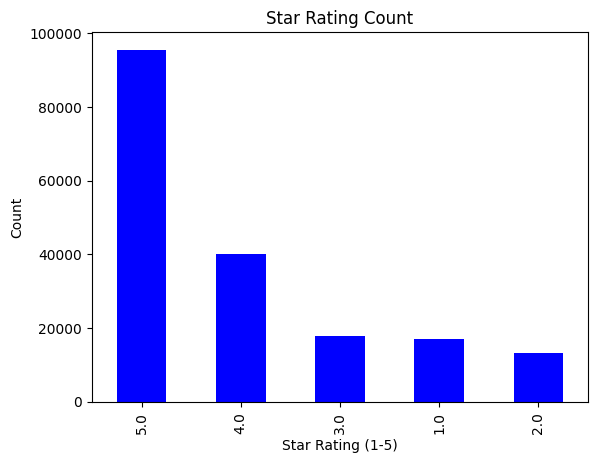

In [18]:

merged_df["stars"].value_counts().plot(kind="bar", color="blue")
plt.title("Star Rating Count")
plt.xlabel("Star Rating (1-5)")
plt.ylabel("Count")

In [19]:
conditions = [
    merged_df["stars"].isin([1, 2]),
    merged_df["stars"] == 3,
    merged_df["stars"].isin([4, 5]),
]

choices = ["negative", "none", "positive"]

merged_df["sentiment"] = np.select(conditions, choices, default=None)

In [20]:
merged_df["token_length"] = merged_df["text"].apply(lambda x: len(word_tokenize(x)))

Text(0, 0.5, 'Count of Reviews')

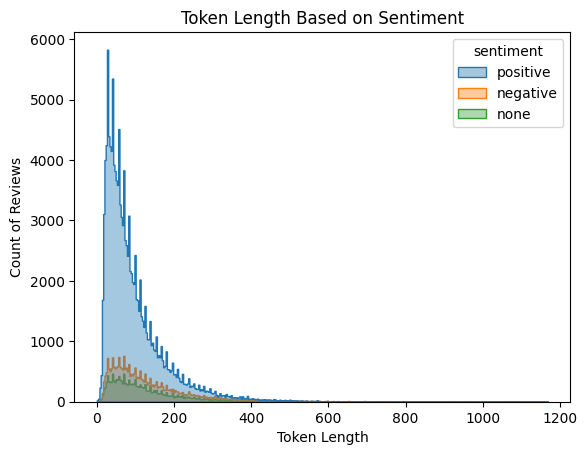

In [21]:
sns.histplot(
    data=merged_df,
    x="token_length",
    hue="sentiment",
    element='step',
    alpha=0.4
)
plt.title("Token Length Based on Sentiment")
plt.xlabel("Token Length")
plt.ylabel("Count of Reviews")

In [22]:
merged_df["categories"].value_counts().head(20)

,count
categories,
"Mexican, Restaurants",6558
"Restaurants, Mexican",5139
"Cocktail Bars, Fish & Chips, Nightlife, Seafood, Restaurants, Bars",3003
"Seafood, Restaurants, Hawaiian, American (New), Breakfast & Brunch",2588
"Live/Raw Food, Restaurants, Seafood, Beer Bar, Beer, Wine & Spirits, Bars, Food, Nightlife",2444
"Garage Door Services, Restaurants, Live/Raw Food, Food, Home Services, Mediterranean, Keys & Locksmiths, Burgers, Vegetarian, Juice Bars & Smoothies, Vegan, Salad",1862
"Food, Coffee & Tea",1636
"Nightlife, Arts & Entertainment, Restaurants, Dance Clubs, Bars, Music Venues, Mexican, Sports Bars",1590
"Nightlife, Bars, Cocktail Bars, Food, American (New), Desserts, Restaurants",1562


In [23]:
merged_df_positive_negative = merged_df[merged_df["sentiment"] != "none"]
sentiment_token_length = merged_df_positive_negative.groupby("sentiment")["token_length"].mean()

Text(0, 0.5, 'Count of Average Length')

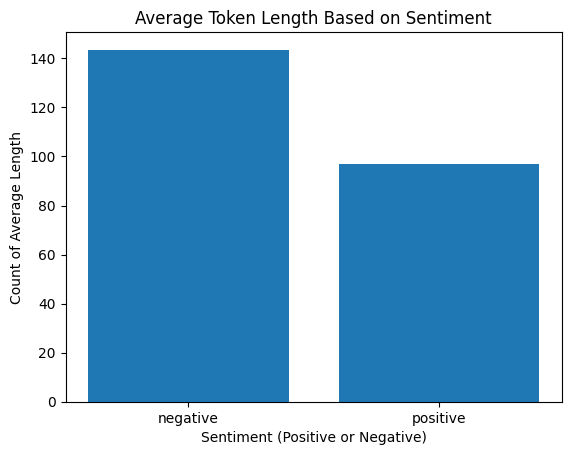

In [24]:
plt.bar(
    x=sentiment_token_length.index,
    height=sentiment_token_length.values
)
plt.title("Average Token Length Based on Sentiment")
plt.xlabel("Sentiment (Positive or Negative)")
plt.ylabel("Count of Average Length")

Text(0, 0.5, 'Count of Reviews')

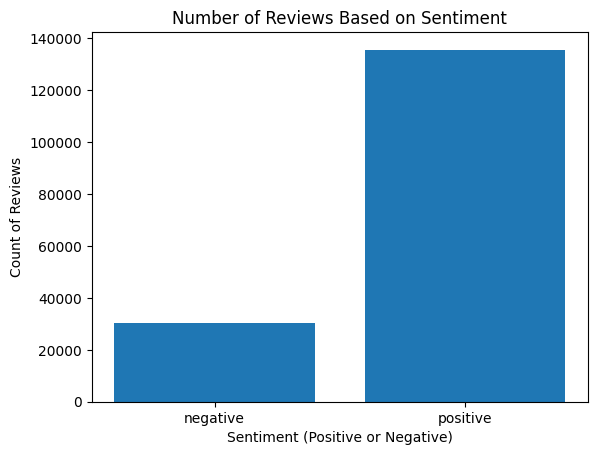

In [25]:
sentiment_count = merged_df_positive_negative.groupby("sentiment").count()
plt.bar(
    x=sentiment_count.index,
    height=sentiment_count.text
)
plt.title("Number of Reviews Based on Sentiment")
plt.xlabel("Sentiment (Positive or Negative)")
plt.ylabel("Count of Reviews")

In [26]:
merged_df_positive_negative["day_of_week"] = merged_df_positive_negative["date"].apply(
    lambda x: datetime.strptime(str(x), "%Y-%m-%d %H:%M:%S").strftime("%A")
)

/tmp/ipykernel_36114/3490492637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_positive_negative["day_of_week"] = merged_df_positive_negative["date"].apply(


Text(0, 0.5, 'Count of Reviews')

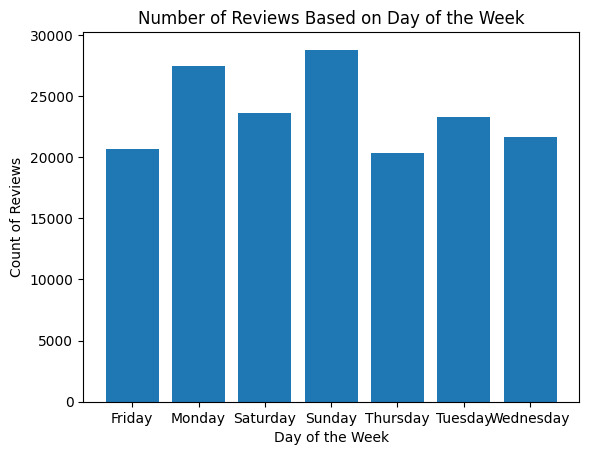

In [27]:
review_count = merged_df_positive_negative.groupby("day_of_week").count()
plt.bar(
    x=review_count.index,
    height=review_count.text
)
plt.title("Number of Reviews Based on Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Count of Reviews")